# Detecting Fraudulent Job Advertisements

This notebook explores a dataset of job advertisements to identify patterns that may indicate fraudulent job postings. The goal is to understand the structure of the dataset, identify potential scam signals, and propose a detection approach.

## Dataset Overview

We first load the dataset and inspect its structure to understand the number of records, available features, and potential data quality issues.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df.head()
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   title                   17880 non-null  str  
 1   location                17534 non-null  str  
 2   department              6333 non-null   str  
 3   salary_range            2868 non-null   str  
 4   company_profile         14572 non-null  str  
 5   description             17880 non-null  str  
 6   requirements            15191 non-null  str  
 7   benefits                10684 non-null  str  
 8   telecommuting           17880 non-null  str  
 9   has_company_logo        17880 non-null  str  
 10  has_questions           17880 non-null  str  
 11  employment_type         14409 non-null  str  
 12  required_experience     10830 non-null  str  
 13  required_education      9775 non-null   str  
 14  industry                12977 non-null  str  
 15  function                11425 

## Data Quality Checks

We examine missing values and data completeness to understand the quality of the dataset. Missing information may also be a useful signal for detecting suspicious job advertisements.

In [39]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

salary_range              15012
department                11547
required_education         8105
benefits                   7196
required_experience        7050
function                   6455
industry                   4903
employment_type            3471
company_profile            3308
requirements               2689
location                    346
title                         0
description                   0
telecommuting                 0
has_questions                 0
has_company_logo              0
fraudulent                    0
in_balanced_dataset           0
title_length                  0
description_length            0
company_profile_length        0
requirements_length           0
dtype: int64

In [40]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percentage

salary_range              83.959732
department                64.580537
required_education        45.329978
benefits                  40.246085
required_experience       39.429530
function                  36.101790
industry                  27.421700
employment_type           19.412752
company_profile           18.501119
requirements              15.039150
location                   1.935123
title                      0.000000
description                0.000000
telecommuting              0.000000
has_questions              0.000000
has_company_logo           0.000000
fraudulent                 0.000000
in_balanced_dataset        0.000000
title_length               0.000000
description_length         0.000000
company_profile_length     0.000000
requirements_length        0.000000
dtype: float64

## Distribution of Fraudulent vs Legitimate Job Ads

We examine the target variable to determine whether the dataset is imbalanced. This is important because fraud detection problems often contain far fewer fraudulent records than legitimate ones.

In [41]:
df["fraudulent"].value_counts()

fraudulent
f    17014
t      866
Name: count, dtype: int64

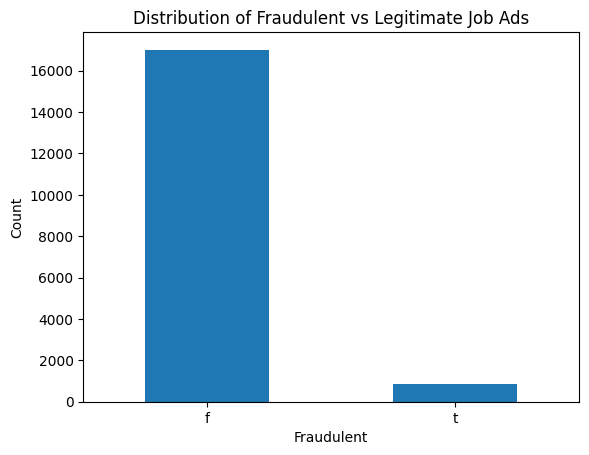

In [42]:
fraud_counts = df["fraudulent"].value_counts()

fraud_counts.plot(kind="bar")
plt.title("Distribution of Fraudulent vs Legitimate Job Ads")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The target variable appears to be imbalanced, with fewer fraudulent postings than legitimate ones. This means that accuracy alone may not be a sufficient evaluation metric for a future model.

## Inspecting Important Text Fields

The dataset contains several text-heavy fields such as job title, company profile, description, requirements, and benefits. These fields may contain useful linguistic signals for distinguishing scam ads from legitimate postings.

In [43]:
df[["title", "company_profile", "description", "requirements", "benefits", "fraudulent"]].head()

,title,company_profile,description,requirements,benefits,fraudulent
0,Marketing Intern,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f
1,Customer Service - Cloud Video Production,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f
2,Commissioning Machinery Assistant (CMA),<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f
3,Account Executive - Washington DC,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f
4,Bill Review Manager,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f


## Creating Simple Text-Based Features

We create simple features such as text length, which may help identify differences between fraudulent and legitimate job advertisements.

In [44]:
df["title_length"] = df["title"].fillna("").apply(len)
df["description_length"] = df["description"].fillna("").apply(len)
df["company_profile_length"] = df["company_profile"].fillna("").apply(len)
df["requirements_length"] = df["requirements"].fillna("").apply(len)

In [45]:
df.groupby("fraudulent")[["title_length", "description_length", "company_profile_length", "requirements_length"]].mean()

,title_length,description_length,company_profile_length,requirements_length
fraudulent,,,,
f,28.421594,1438.659281,713.553838,742.532797
t,30.666282,1436.377598,305.646651,512.357968


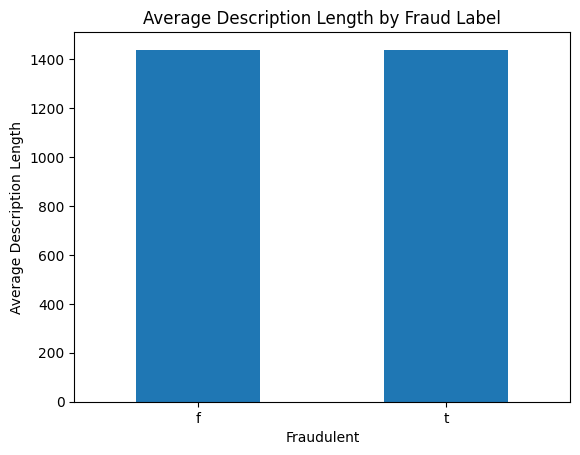

In [46]:
df.groupby("fraudulent")["description_length"].mean().plot(kind="bar")
plt.title("Average Description Length by Fraud Label")
plt.xlabel("Fraudulent")
plt.ylabel("Average Description Length")
plt.xticks(rotation=0)
plt.show()

## Missing Information as a Potential Scam Signal

Fraudulent advertisements may omit important fields such as company profiles, requirements, or benefits. We compare missing-value patterns across fraudulent and legitimate postings.

In [47]:
pd.crosstab(df["company_profile"].isnull(), df["fraudulent"], margins=True)

fraudulent,f,t,All
company_profile,,,
False,14293,279,14572
True,2721,587,3308
All,17014,866,17880


In [48]:
pd.crosstab(df["requirements"].isnull(), df["fraudulent"], margins=True)

fraudulent,f,t,All
requirements,,,
False,14478,713,15191
True,2536,153,2689
All,17014,866,17880


In [49]:
pd.crosstab(df["benefits"].isnull(), df["fraudulent"], margins=True)

fraudulent,f,t,All
benefits,,,
False,10181,503,10684
True,6833,363,7196
All,17014,866,17880


## Structured Feature Exploration

We also examine structured variables such as telecommuting, presence of company logo, and screening questions, as these may help distinguish scam postings from legitimate ones.

In [50]:
for col in ["telecommuting", "has_company_logo", "has_questions"]:
    print(f"\nColumn: {col}")
    print(pd.crosstab(df[col], df["fraudulent"], normalize="index"))


Column: telecommuting
fraudulent            f         t
telecommuting                    
f              0.953135  0.046865
t              0.916558  0.083442

Column: has_company_logo
fraudulent               f         t
has_company_logo                    
f                 0.840710  0.159290
t                 0.980098  0.019902

Column: has_questions
fraudulent            f         t
has_questions                    
f              0.932218  0.067782
t              0.971565  0.028435


## Simple Keyword Exploration

We create a combined text field and check for suspicious keywords that may appear more frequently in fraudulent advertisements.

In [51]:
df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["company_profile"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("") + " " +
    df["benefits"].fillna("")
)

In [ ]:
suspicious_keywords = [
    "work from home",
    "earn money",
    "quick money",
    "no experience",
    "urgent",
    "whatsapp",
    "telegram"
]

for word in suspicious_keywords:
    df[f"kw_{word.replace(' ', '_')}"] = df["combined_text"].str.lower().str.contains(word, na=False)

df[[col for col in df.columns if col.startswith("kw_")]].sum().sort_values(ascending=False)

In [ ]:
keyword_cols = [col for col in df.columns if col.startswith("kw_")]

df.groupby("fraudulent")[keyword_cols].mean().T

## Candidate Features for Fraud Detection

Based on the exploratory analysis, useful features may include text length features, missing company information, telecommuting indicators, suspicious keyword flags, and vectorised text representations such as TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=1000)
X_tfidf = tfidf.fit_transform(df["combined_text"].fillna(""))
print(X_tfidf.shape)

## Summary of Findings and Proposed Approach

Potential scam indicators include missing company information, differences in text length, suspicious keyword usage, and structured signals such as telecommuting or lack of screening questions.

A practical next step would be to combine:
- rule-based features (e.g. missing company profile, suspicious keywords),
- structured metadata features, and
- text features such as TF-IDF.

A suitable baseline model would be Logistic Regression due to its simplicity, interpretability, and effectiveness on sparse text data. Since fraud is likely the minority class, evaluation should prioritize precision, recall, and F1-score rather than accuracy alone.